# Check states
Created 30/04/2026

Objectives:
* Check states saved [here](../../save_states/finite_cluster_x_transverse_to_product_stacked_cluster_200_site.ipynb). and [here](../../save_states/finite_x_product_stacked_transverse_y_cluster_to_product_200_site.ipynb)

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [6]:
DATA_DIR_1 = r"../../data/finite_cluster_x_transverse_to_product_stacked_cluster_200_site"
DATA_DIR_2 = r"../../data/finite_x_product_stacked_transverse_y_cluster_to_product_200_site"

In [14]:
loaded_data_1 = list()

for local_file_name in os.listdir(DATA_DIR_1):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_1, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_1.append(data)

loaded_data_2 = list()

for local_file_name in os.listdir(DATA_DIR_2):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_2, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_2.append(data)

In [15]:
loaded_data_1[0]

{'energy': -186.48912111470472,
 'paramters': {'interpolation': 0.1},
 'wavefunction': <tenpy.networks.mps.MPS at 0x7f6682578690>}

In [16]:
interpolation_values_1 = sorted(list(d['paramters']['interpolation'] for d in loaded_data_1))
interpolation_values_2 = sorted(list(d['paramters']['interpolation'] for d in loaded_data_2))

In [17]:
interpolation_values_1

[0.0,
 0.1,
 0.2,
 0.30000000000000004,
 0.4,
 0.5,
 0.6000000000000001,
 0.7000000000000001,
 0.8,
 0.9,
 1.0]

In [18]:
interpolation_values_2

[0.0,
 0.1,
 0.2,
 0.30000000000000004,
 0.4,
 0.5,
 0.6000000000000001,
 0.7000000000000001,
 0.8,
 0.9,
 1.0]

# Definitions

In [21]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [22]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [23]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

# Analysis
## Energies

In [25]:
values_1 = list()
energies_1 = list()

for d in loaded_data_1:
    values_1.append(d['paramters']['interpolation'])
    energies_1.append(d['energy'])

In [26]:
values_2 = list()
energies_2 = list()

for d in loaded_data_2:
    values_2.append(d['paramters']['interpolation'])
    energies_2.append(d['energy'])

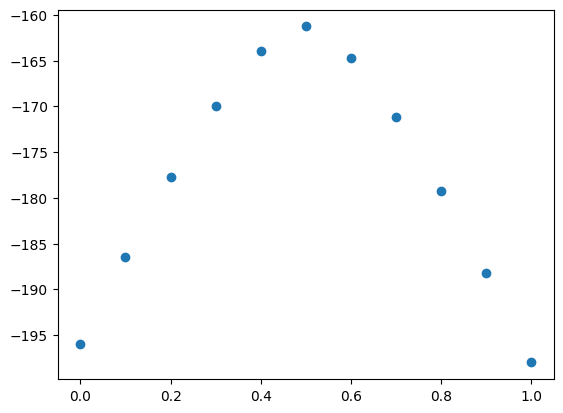

In [28]:
plt.plot(values_1, energies_1, 'o')

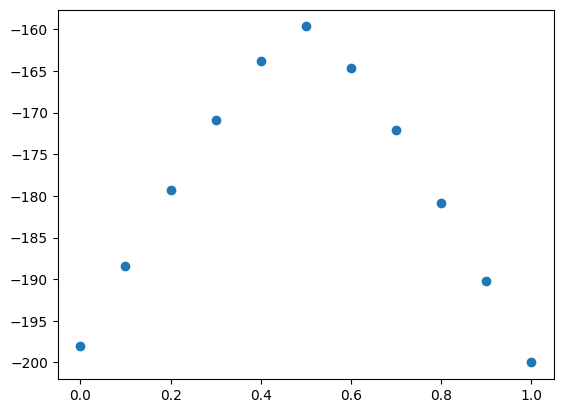

In [29]:
plt.plot(values_2, energies_2, 'o')

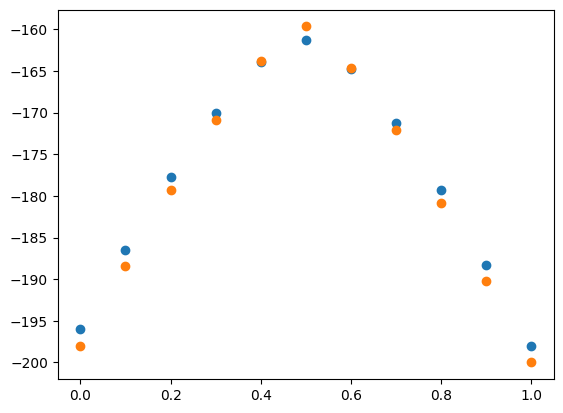

In [30]:
plt.plot(values_1, energies_1, 'o')
plt.plot(values_2, energies_2, 'o')

Critical point at $t=0.5$...?

## Expectation values

In [37]:
values_1 = list()
exps_1 = list()

for d in loaded_data_1:
    values_1.append(d['paramters']['interpolation'])
    psi = d['wavefunction']
    exp_hex = (
        psi.expectation_value('Sx', 100),
        psi.expectation_value('Sy', 100),
        psi.expectation_value('Sz', 100),
        psi.expectation_value('Sx', 101),
        psi.expectation_value('Sy', 101),
        psi.expectation_value('Sz', 101),
    )
    exps_1.append(exp_hex)

exps_1 = np.array(exps_1)

In [38]:
labels = [
    'X - X',
    'X - Y',
    'X - X',
    'XK - X',
    'XK - Y',
    'XK - X'
]

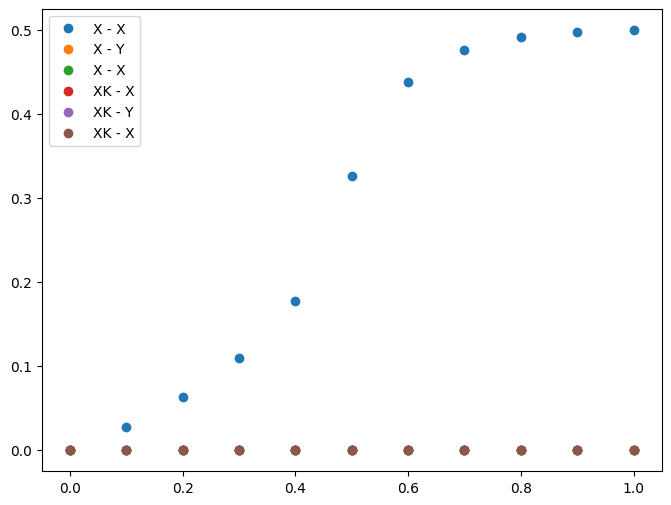

In [42]:
fig, ax = plt.subplots(figsize=(8,6))

for i, l in enumerate(labels):
    ax.plot(values_1, exps_1[:, i], 'o', label=l)

ax.legend()

In [47]:
values_2 = list()
exps_2 = list()

for d in loaded_data_2:
    values_2.append(d['paramters']['interpolation'])
    psi = d['wavefunction']
    exp_hex = (
        psi.expectation_value('Sx', 100),
        psi.expectation_value('Sy', 100),
        psi.expectation_value('Sz', 100),
        psi.expectation_value('Sx', 101),
        psi.expectation_value('Sy', 101),
        psi.expectation_value('Sz', 101),
    )
    exps_2.append(exp_hex)

exps_2 = np.array(exps_2)

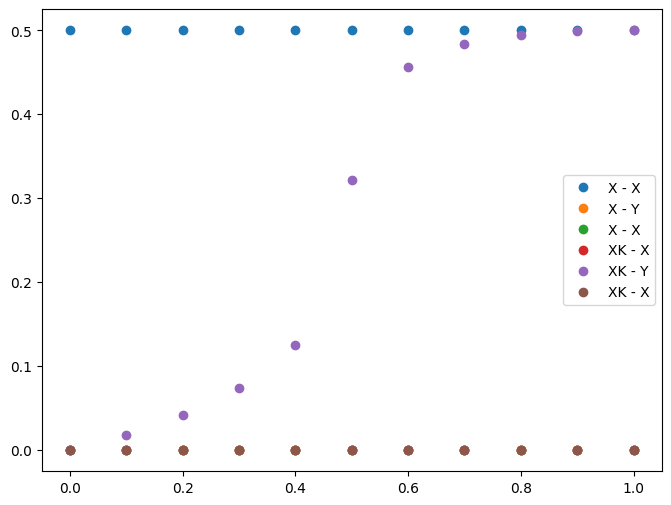

In [48]:
fig, ax = plt.subplots(figsize=(8,6))

for i, l in enumerate(labels):
    ax.plot(values_1, exps_2[:, i], 'o', label=l)

ax.legend()

In [49]:
np.round(exps_2, 3)

array([[[ 0.5  ],
        [ 0.   ],
        [-0.   ],
        [ 0.   ],
        [ 0.019],
        [-0.   ]],

       [[ 0.5  ],
        [-0.   ],
        [ 0.   ],
        [-0.   ],
        [ 0.5  ],
        [ 0.   ]],

       [[ 0.5  ],
        [ 0.   ],
        [-0.   ],
        [-0.   ],
        [ 0.321],
        [ 0.   ]],

       [[ 0.5  ],
        [ 0.   ],
        [-0.   ],
        [ 0.   ],
        [ 0.499],
        [ 0.   ]],

       [[ 0.5  ],
        [-0.   ],
        [-0.   ],
        [-0.   ],
        [ 0.484],
        [-0.   ]],

       [[ 0.5  ],
        [ 0.   ],
        [-0.   ],
        [-0.   ],
        [ 0.   ],
        [ 0.   ]],

       [[ 0.5  ],
        [ 0.   ],
        [ 0.   ],
        [-0.   ],
        [ 0.125],
        [ 0.   ]],

       [[ 0.5  ],
        [-0.   ],
        [-0.   ],
        [-0.   ],
        [ 0.042],
        [ 0.   ]],

       [[ 0.5  ],
        [-0.   ],
        [-0.   ],
        [ 0.   ],
        [ 0.456],
        [-0.   ]],

       [[ 

# Conclusions
Looks good.